# Chapter 57: PatchTST for Time Series and HAR

**Does patching beat a feature baseline at the same forward origins, and how does the patch length change the answer and the token count?**

A sequence representation is only worth its cost if it beats a credible feature baseline on matched origins. The patch length decides how many tokens the model processes and whether one token can hold the shape that matters.

*Constructed series in which a local shape matters by design, and a stand-in model. The advantage of patching over the feature baseline here is modest (about 7% in MAE at P = 12), and gradient boosting on the raw 96 values matches it (0.409 against 0.414), so the gain comes from seeing the shape of the whole window, which the lag features miss, rather than from patching itself. This is not evidence about PatchTST on any real competition.*

## The experiment

Six constructed sets of 30 series of 640 steps: a 24-step and 12-step cycle, random pulses (a 10-step damped oscillation followed 16 steps later by a rebound that depends on the pulse size) and autocorrelated noise. Every model sees a 96-step window and forecasts the value 12 steps after it, and is scored by mean absolute error (MAE) on windows taken after the last training step. The patch model unfolds the window into patches of length P with 50% overlap, embeds every patch with one shared PCA projection to 4 numbers, and feeds the concatenated tokens to gradient boosting; there is no attention. The comparators are a seasonal-naive forecast, gradient boosting on lag and rolling features, and gradient boosting on the raw 96 values.

In [1]:
from functools import lru_cache

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor

from kaggle_companion.activities._common import clean

SEED = 57
REPLICATES = 6                       # independent sets of series; every estimate is their mean
SERIES, LENGTH, SPLIT = 30, 640, 420  # series per set, steps per series, last training step
WINDOW, HORIZON = 96, 12             # the model sees 96 steps and forecasts the value 12 steps after the last one
PULSE_RATE = 0.02                    # chance per step that a pulse starts
EMBED = 4                            # width of the learned embedding of each patch


def generate(rng):
    """Daily-style cycle (period 24 and 12) plus random pulses and AR noise. A pulse is a 10-step damped oscillation
    followed 16 steps after its start by a rebound whose height depends on |pulse size|, a nonlinear, local-shape effect."""
    t = np.arange(LENGTH)
    series = []
    for _ in range(SERIES):
        phase = rng.uniform(0, 24)
        y = rng.uniform(0.8, 1.2) * np.sin(2 * np.pi * (t + phase) / 24) + 0.4 * np.sin(2 * np.pi * (t + phase) / 12 + 1)
        for s in np.flatnonzero(rng.random(LENGTH) < PULSE_RATE):
            size = rng.choice([-1, 1]) * rng.uniform(1.0, 2.0)
            n = min(30, LENGTH - s)
            k = np.arange(n)
            y[s:s + n] += size * np.exp(-k / 10) * np.sin(2 * np.pi * k / 10)
            m = min(12, LENGTH - (s + 16))
            if m > 0:
                y[s + 16:s + 16 + m] += abs(size) * np.exp(-0.5 * ((np.arange(m) - 4) / 3.0) ** 2)
        noise = np.zeros(LENGTH)
        for i in range(1, LENGTH):
            noise[i] = 0.5 * noise[i - 1] + rng.normal(0, 0.15)
        series.append(y + noise)
    return np.array(series)


def make_windows(series, first, last, stride=3):
    """Input windows of 96 steps and the target 12 steps after the last input, all inside [first, last)."""
    X, y = [], []
    for s in series:
        for end in range(first + WINDOW, last - HORIZON + 1, stride):
            X.append(s[end - WINDOW:end])
            y.append(s[end - 1 + HORIZON])
    return np.array(X), np.array(y)


def patches(X, patch_length, stride):
    """(windows, tokens, patch_length): the same unfold as the chapter's temporal_patches, on a plain array."""
    out = sliding_window_view(X, patch_length, axis=1)[:, ::stride, :]
    assert out.shape[1] == (WINDOW - patch_length) // stride + 1, "token count must be floor((T-P)/S)+1"
    return out


def feature_baseline(X):
    """Lags and short rolling statistics: the 'feature-engineered' comparator."""
    cols = [X[:, -k] for k in (1, 2, 3, 6, 12, 24, 48)]
    cols += [X[:, -24:].mean(1), X[:, -24:].std(1), X[:, -12:].mean(1), X[:, -12:].std(1)]
    return np.column_stack(cols)


def patch_tokens(X_train, X_test, patch_length):
    """Stand-in for a patch embedding: a projection shared by all patches (PCA fitted on training patches only),
    applied to every patch, with the tokens concatenated. There is no attention layer."""
    stride = patch_length // 2                                    # 50% overlap
    train, test = patches(X_train, patch_length, stride), patches(X_test, patch_length, stride)
    pca = PCA(EMBED, random_state=0).fit(train.reshape(-1, patch_length))
    embed = lambda Z: pca.transform(Z.reshape(-1, patch_length)).reshape(len(Z), -1)
    return embed(train), embed(test), train.shape[1]


@lru_cache(maxsize=None)
def make_split(seed, replicate):
    """One set of series cut into training windows (targets before step 420) and forward test windows (after it)."""
    series = generate(np.random.default_rng(seed * 100 + replicate))
    return (*make_windows(series, 0, SPLIT), *make_windows(series, SPLIT, LENGTH))


@lru_cache(maxsize=None)
def baselines(seed, replicate):
    """Comparators that do not depend on the patch length, computed once per set."""
    X_train, y_train, X_test, y_test = make_split(seed, replicate)
    mae = lambda pred: float(np.mean(np.abs(pred - y_test)))
    return {"seasonal_naive": mae(X_test[:, WINDOW - 1 + HORIZON - 24]),   # the value one cycle (24 steps) before the target
            "features": mae(new_model().fit(feature_baseline(X_train), y_train).predict(feature_baseline(X_test))),
            "raw_window": mae(new_model().fit(X_train, y_train).predict(X_test))}


def new_model():
    return HistGradientBoostingRegressor(max_iter=60, learning_rate=0.12, max_leaf_nodes=15, random_state=0)


def one_set(patch_length, replicate):
    X_train, y_train, X_test, y_test = make_split(SEED, replicate)
    mae = lambda pred: float(np.mean(np.abs(pred - y_test)))
    P_train, P_test, tokens = patch_tokens(X_train, X_test, patch_length)
    return {**baselines(SEED, replicate),
            "patch": mae(new_model().fit(P_train, y_train).predict(P_test)), "tokens": tokens, "windows": len(y_test)}


def run(patch_length):
    sets = [one_set(patch_length, i) for i in range(REPLICATES)]
    keys = ["seasonal_naive", "features", "raw_window", "patch"]
    return clean({
        "patch_length": patch_length, "stride": patch_length // 2, "tokens": sets[0]["tokens"],
        "token_pairs": sets[0]["tokens"] ** 2,                  # attention cost grows with tokens squared
        **{k: float(np.mean([s[k] for s in sets])) for k in keys},
        "per_set": {k: [s[k] for s in sets] for k in keys},
        "replicates": REPLICATES, "test_windows": sets[0]["windows"],
    })


## Measure it across the control

The control is **patch length p in steps (stride is p/2; the pulse oscillation lasts 10)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch57 import explain

VALUES = [4, 12, 24, 48]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                          4     12     24     48
Patch-token MAE       0.389  0.414  0.461  0.476
Feature baseline MAE  0.447  0.447  0.447  0.447
Raw window MAE        0.409  0.409  0.409  0.409
Seasonal naive MAE    0.653  0.653  0.653  0.653
Tokens per window        47     15      7      3


## Look at it

The figure shows the default setting, patch length p in steps (stride is p/2; the pulse oscillation lasts 10) = 12.

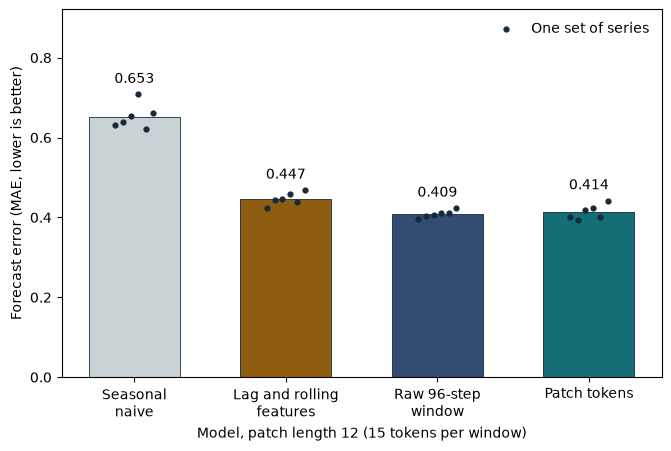

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch57 import draw, NCOLS, HEIGHT

DEFAULT = 12
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With patches of 12 steps (stride 6) each 96-step window becomes 15 tokens, floor((96 - 12) / 6) + 1 = 15. The patch model scores an MAE of 0.414 and beats the feature baseline at 0.447, so 0.447 - 0.414 = 0.033 separates them. The raw 96-step window scores 0.409 and the seasonal-naive forecast 0.653. Attention would relate 225 pairs of tokens per window.

- Tokens: floor((96 - 12) / 6) + 1 = 15.
- Feature baseline minus patch model: 0.447 - 0.414 = +0.033 (positive means patching is better).
- Raw window minus patch model: 0.409 - 0.414 = -0.005.
- Token pairs for attention: 15 x 15 = 225.

## Apply this to your competition

- Compute the exact token count floor((T - P)/S) + 1 for each candidate patch length before any long run.
- Compare the sequence model with a feature baseline and a raw-window baseline on the same forward origins and the same metric.
- Choose the patch length from the duration of the events and the sampling rate, then test one longer and one shorter patch.
- Report the cost (tokens, feature extraction, inference time) next to the score; a small gain from many more tokens is a decision, not a free win.

Book location: Chapter 57, PatchTST vs. Feature-Engineered GBM: When to Use Each.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)